In [ ]:
# Mount Google Drive
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

drive.mount('/content/drive')

# Define project path in Drive
PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
os.makedirs(PROJECT_PATH, exist_ok=True)

Mounted at /content/drive


In [ ]:
# Dataset load
import pandas as pd
RAW_PATH = os.path.join(PROJECT_PATH, "results/output/heart_dataset_final.csv")
df = pd.read_csv(RAW_PATH)
print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (1025, 12)


,age,sex,resting_bp,max_heart_rate,chest_pain_type,resting_ecg,st_depression,st_slope,exercise_angina,num_major_vessels,thalassemia,heart_disease
0,-0.268437,0.661504,-0.377636,0.821321,-0.915755,0.891255,-0.060888,0.995433,-0.712287,1.209221,1.089852,0
1,-0.158157,0.661504,0.479107,0.255968,-0.915755,-1.004049,1.727137,-2.243675,1.403928,-0.731971,1.089852,0
2,1.716595,0.661504,0.764688,-1.048692,-0.915755,0.891255,1.301417,-2.243675,1.403928,-0.731971,1.089852,0
3,0.724079,0.661504,0.936037,0.516900,-0.915755,0.891255,-0.912329,0.995433,-0.712287,0.238625,1.089852,0
4,0.834359,-1.511706,0.364875,-1.874977,-0.915755,0.891255,0.705408,-0.624121,-0.712287,1.694519,-0.522122,0


In [ ]:
# IT24102775 : Decision Tree Implementation
# =====================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns


# 1. MODEL SELECTION AND JUSTIFICATION
print("\n1. MODEL SELECTION AND JUSTIFICATION")
print("""
Why Decision Tree for Heart Disease Prediction:
- Highly interpretable for medical professionals
- Handles both numerical and categorical features
- No need for feature scaling
- Provides clear decision rules for diagnosis
- Feature importance for clinical insights
- Can capture non-linear relationships
- White-box model suitable for healthcare
- Creates clinical decision pathways
""")

# Display dataset info
print(f"Dataset shape: {df.shape}")
print(f"Features: {list(df.columns)}")
print(f"Target distribution:\n{df['heart_disease'].value_counts()}")

# Prepare features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']
feature_names = X.columns.tolist()

print(f"\nFeature names: {feature_names}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class distribution in training set: {np.bincount(y_train)}")
print(f"Class distribution in test set: {np.bincount(y_test)}")

# Handle class imbalance with SMOTE
print("\nApplying SMOTE for class imbalance...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE - Training set: {X_train_smote.shape}")
print(f"After SMOTE - Class distribution: {np.bincount(y_train_smote)}")


1. MODEL SELECTION AND JUSTIFICATION

Why Decision Tree for Heart Disease Prediction:
- Highly interpretable for medical professionals
- Handles both numerical and categorical features
- No need for feature scaling
- Provides clear decision rules for diagnosis
- Feature importance for clinical insights
- Can capture non-linear relationships
- White-box model suitable for healthcare
- Creates clinical decision pathways

Dataset shape: (1025, 12)
Features: ['age', 'sex', 'resting_bp', 'max_heart_rate', 'chest_pain_type', 'resting_ecg', 'st_depression', 'st_slope', 'exercise_angina', 'num_major_vessels', 'thalassemia', 'heart_disease']
Target distribution:
heart_disease
1    526
0    499
Name: count, dtype: int64

Feature names: ['age', 'sex', 'resting_bp', 'max_heart_rate', 'chest_pain_type', 'resting_ecg', 'st_depression', 'st_slope', 'exercise_angina', 'num_major_vessels', 'thalassemia']
Training set: (717, 11)
Test set: (308, 11)
Class distribution in training set: [349 368]
Class di

In [ ]:
# 2. IMPLEMENTATION DETAILS
print("\n2. IMPLEMENTATION DETAILS")

# Base Decision Tree
print("\nBase Model Implementation")
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)
y_pred_base = dt_base.predict(X_test)


2. IMPLEMENTATION DETAILS

Base Model Implementation


In [ ]:
# 3. PARAMETER TUNING METHODS
print("\n3. PARAMETER TUNING WITH RANDOMIZEDSEARCHCV")

# Define parameter distribution
param_dist = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 5, 10, 15],
    'max_features': ['sqrt', 'log2', None, 0.5, 0.7, 0.9],
    'class_weight': ['balanced', None]
}

# RandomizedSearchCV for hyperparameter tuning
dt_random = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Performing hyperparameter tuning...")
dt_random.fit(X_train, y_train)

print(f"Best parameters: {dt_random.best_params_}")
print(f"Best cross-validation score: {dt_random.best_score_:.4f}")

# Train best model
best_dt = dt_random.best_estimator_


3. PARAMETER TUNING WITH RANDOMIZEDSEARCHCV
Performing hyperparameter tuning...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters: {'splitter': 'random', 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.9, 'max_depth': 7, 'criterion': 'gini', 'class_weight': None}
Best cross-validation score: 0.9245


In [ ]:
# 4. MODEL VARIETIES
print("\n4. MODEL VARIETIES IMPLEMENTED")

# Variety 1: Base decision tree
dt_v1 = DecisionTreeClassifier(random_state=42)
dt_v1.fit(X_train, y_train)

# Variety 2: Pruned tree (limited depth)
dt_v2 = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_v2.fit(X_train, y_train)

# Variety 3: Class-weighted tree
dt_v3 = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_v3.fit(X_train, y_train)

# Variety 4: Tuned decision tree
dt_v4 = best_dt

# Variety 5: Tree with SMOTE
dt_v5 = DecisionTreeClassifier(random_state=42)
dt_v5.fit(X_train_smote, y_train_smote)

# Variety 6: Minimal leaf samples
dt_v6 = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
dt_v6.fit(X_train, y_train)

# Variety 7: Clinical interpretable tree (shallow)
dt_v7 = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42)
dt_v7.fit(X_train, y_train)

varieties = {
    'Base DT': dt_v1,
    'Pruned DT (max_depth=5)': dt_v2,
    'Class-Weighted DT': dt_v3,
    'Tuned DT': dt_v4,
    'DT with SMOTE': dt_v5,
    'Min Leaf Samples DT': dt_v6,
    'Clinical DT (max_depth=3)': dt_v7
}


4. MODEL VARIETIES IMPLEMENTED


In [ ]:
# 5. EVALUATION METRICS
print("\n5. COMPREHENSIVE EVALUATION")

def evaluate_dt_variety(model, X_test, y_test, variety_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Tree Depth': model.get_depth(),
        'Number of Leaves': model.get_n_leaves()
    }

    print(f"\n{variety_name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value}")

    return metrics

# Evaluate all varieties
results = {}
for name, model in varieties.items():
    results[name] = evaluate_dt_variety(model, X_test, y_test, name)


5. COMPREHENSIVE EVALUATION

Base DT:
  Accuracy: 0.9707792207792207
  Precision: 1.0
  Recall: 0.9430379746835443
  F1-Score: 0.9706840390879479
  ROC-AUC: 0.9715189873417722
  Tree Depth: 9
  Number of Leaves: 55

Pruned DT (max_depth=5):
  Accuracy: 0.8571428571428571
  Precision: 0.8475609756097561
  Recall: 0.879746835443038
  F1-Score: 0.8633540372670807
  ROC-AUC: 0.9177426160337553
  Tree Depth: 5
  Number of Leaves: 25

Class-Weighted DT:
  Accuracy: 0.9707792207792207
  Precision: 1.0
  Recall: 0.9430379746835443
  F1-Score: 0.9706840390879479
  ROC-AUC: 0.9715189873417722
  Tree Depth: 10
  Number of Leaves: 58

Tuned DT:
  Accuracy: 0.9090909090909091
  Precision: 0.922077922077922
  Recall: 0.8987341772151899
  F1-Score: 0.9102564102564102
  ROC-AUC: 0.9645569620253164
  Tree Depth: 7
  Number of Leaves: 51

DT with SMOTE:
  Accuracy: 0.9707792207792207
  Precision: 1.0
  Recall: 0.9430379746835443
  F1-Score: 0.9706840390879479
  ROC-AUC: 0.9715189873417722
  Tree Depth:

In [ ]:
# 6. CROSS-VALIDATION
print("\n6. CROSS-VALIDATION RESULTS")
cv_scores = cross_val_score(best_dt, X_train, y_train, cv=5, scoring='f1')
print(f"Cross-validation F1 scores: {cv_scores}")
print(f"Mean CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


6. CROSS-VALIDATION RESULTS
Cross-validation F1 scores: [0.87323944 0.94193548 0.94520548 0.94594595 0.91612903]
Mean CV F1: 0.9245 (+/- 0.0558)


In [ ]:
# 7. FEATURE IMPORTANCE ANALYSIS
print("\n7. FEATURE IMPORTANCE ANALYSIS")

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': best_dt.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance Ranking:")
print(feature_importance)



7. FEATURE IMPORTANCE ANALYSIS

Feature Importance Ranking:
              feature  importance
4     chest_pain_type    0.350429
9   num_major_vessels    0.164546
10        thalassemia    0.123853
3      max_heart_rate    0.116645
5         resting_ecg    0.050965
6       st_depression    0.038452
8     exercise_angina    0.036033
0                 age    0.034979
7            st_slope    0.031382
1                 sex    0.027197
2          resting_bp    0.025520


In [ ]:
# 8. MODEL COMPARISON AND INSIGHTS
print("\n8. MODEL COMPARISON AND INSIGHTS")

comparison_df = pd.DataFrame(results).T
print("\nDecision Tree Varieties Comparison:")
print(comparison_df.round(4))

best_variety_dt = comparison_df['F1-Score'].idxmax()
print(f"\nBest performing variety: {best_variety_dt}")
print(f"Best F1-Score: {comparison_df.loc[best_variety_dt, 'F1-Score']:.4f}")


8. MODEL COMPARISON AND INSIGHTS

Decision Tree Varieties Comparison:
                           Accuracy  Precision  Recall  F1-Score  ROC-AUC  \
Base DT                      0.9708     1.0000  0.9430    0.9707   0.9715   
Pruned DT (max_depth=5)      0.8571     0.8476  0.8797    0.8634   0.9177   
Class-Weighted DT            0.9708     1.0000  0.9430    0.9707   0.9715   
Tuned DT                     0.9091     0.9221  0.8987    0.9103   0.9646   
DT with SMOTE                0.9708     1.0000  0.9430    0.9707   0.9715   
Min Leaf Samples DT          0.8669     0.8726  0.8671    0.8698   0.9430   
Clinical DT (max_depth=3)    0.8474     0.8364  0.8734    0.8545   0.9006   

                           Tree Depth  Number of Leaves  
Base DT                           9.0              55.0  
Pruned DT (max_depth=5)           5.0              25.0  
Class-Weighted DT                10.0              58.0  
Tuned DT                          7.0              51.0  
DT with SMOTE         


9. GENERATING VISUALIZATIONS


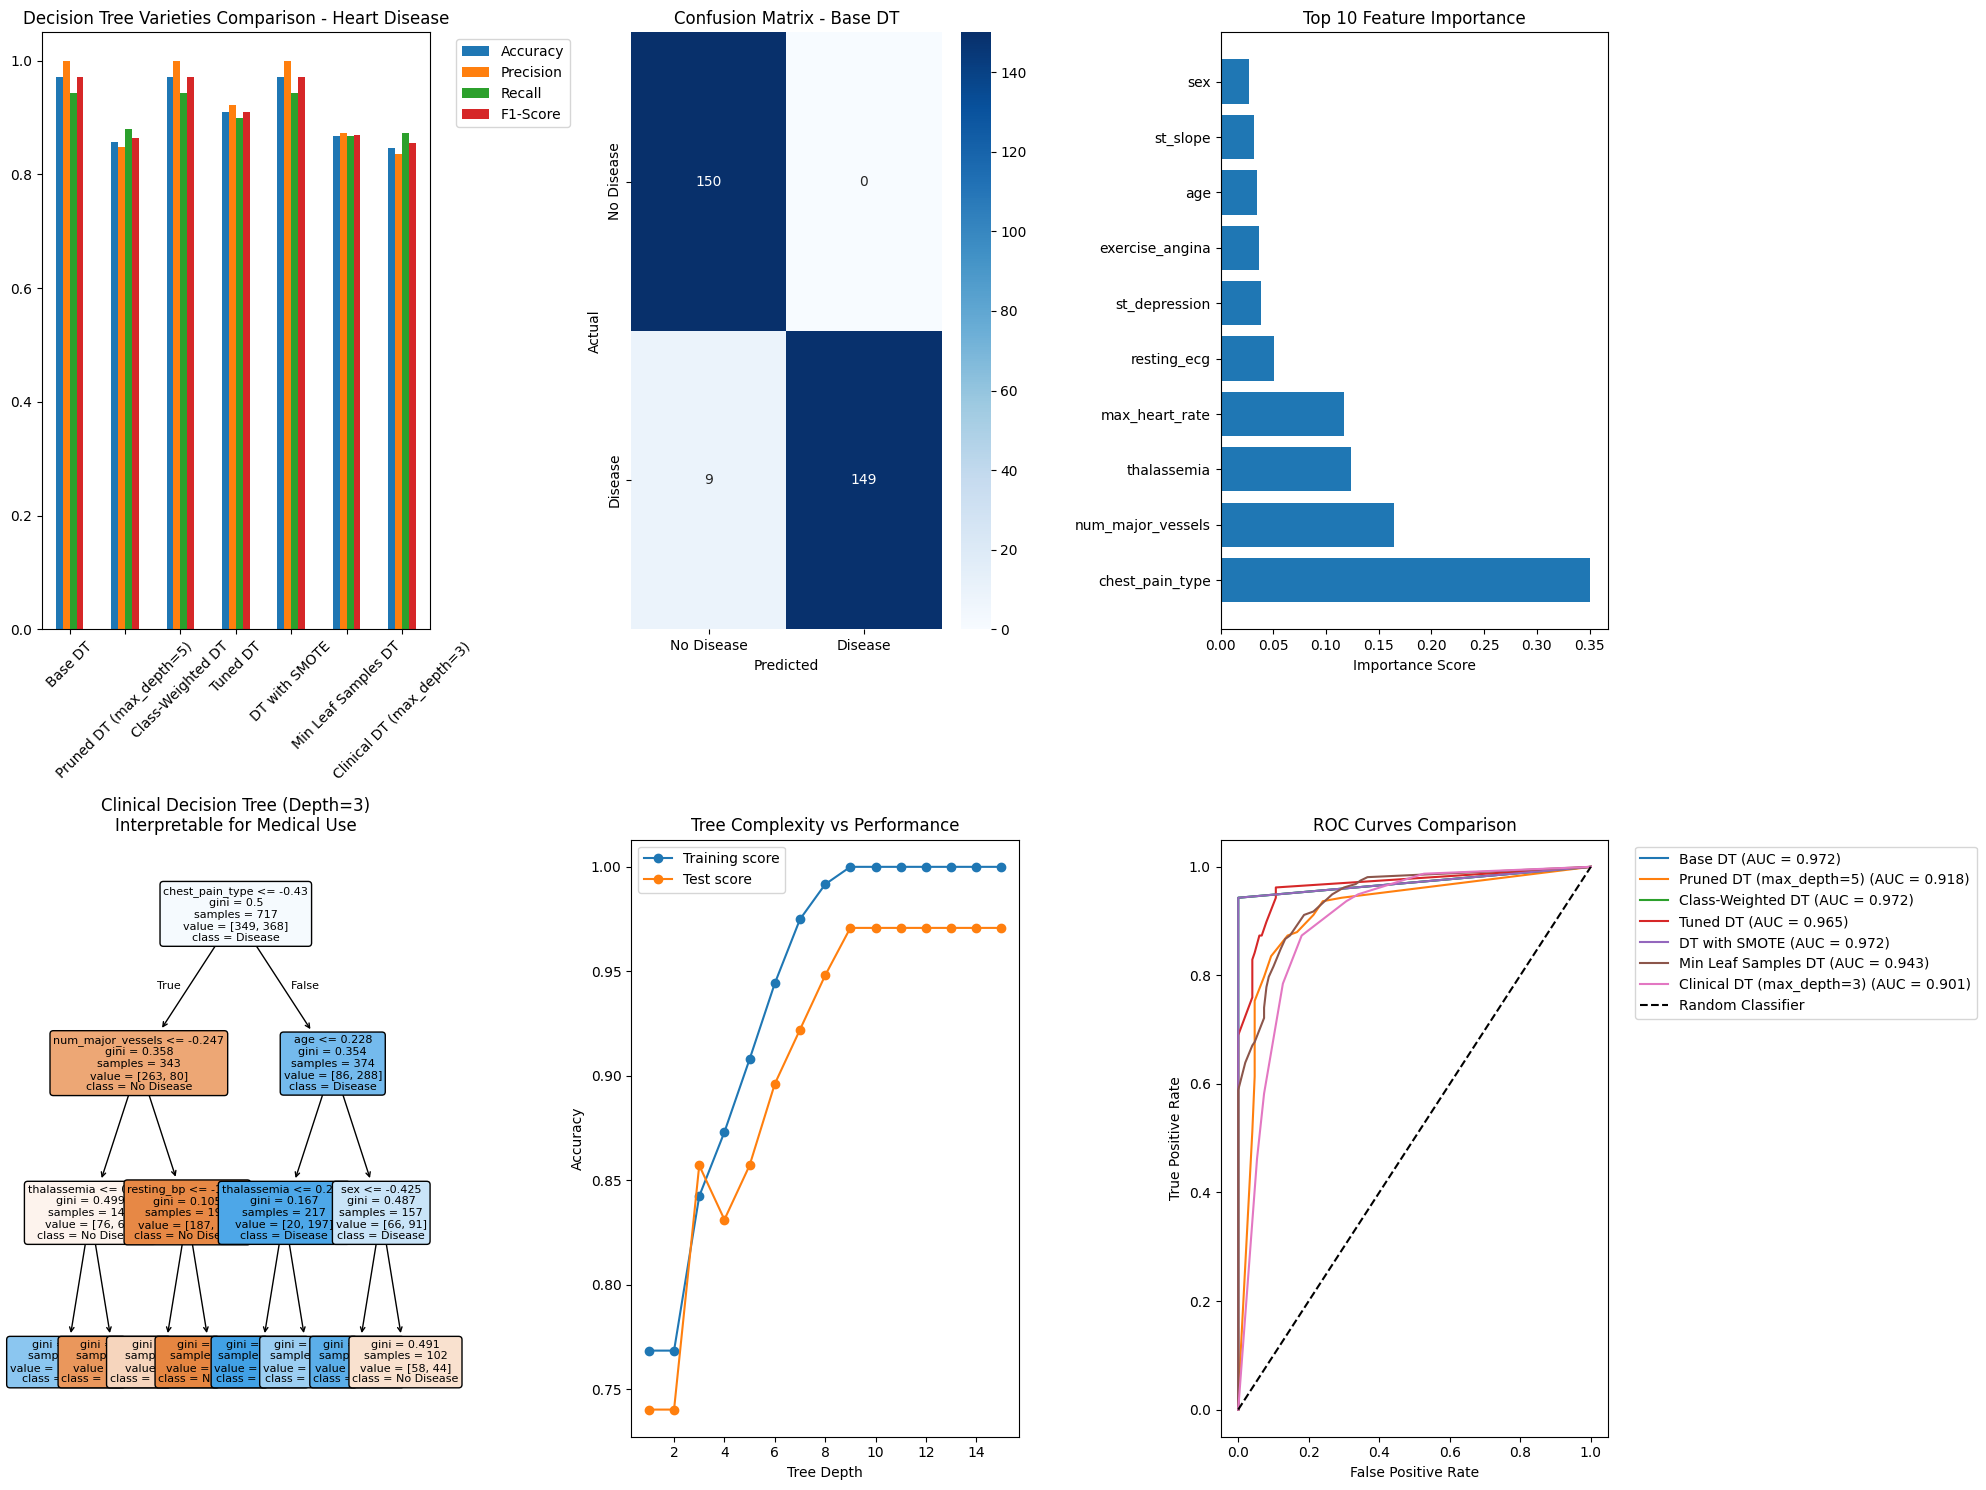

In [ ]:
# 9. VISUALIZATION
print("\n9. GENERATING VISUALIZATIONS")

plt.figure(figsize=(20, 15))

# Plot 1: Metrics comparison
plt.subplot(2, 3, 1)
metrics_plot = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
metrics_plot.plot(kind='bar', ax=plt.gca())
plt.title('Decision Tree Varieties Comparison - Heart Disease')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 2: Confusion Matrix for best model
plt.subplot(2, 3, 2)
best_model = varieties[best_variety_dt]
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - {best_variety_dt}')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Plot 3: Feature importance
plt.subplot(2, 3, 3)
top_features = feature_importance.head(10)
plt.barh(top_features['feature'], top_features['importance'])
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance Score')

# Plot 4: Tree visualization (clinical interpretable version)
plt.subplot(2, 3, 4)
plot_tree(dt_v7, filled=True, feature_names=feature_names,
          class_names=['No Disease', 'Disease'], fontsize=8, rounded=True)
plt.title('Clinical Decision Tree (Depth=3)\nInterpretable for Medical Use')

# Plot 5: Tree complexity vs performance
plt.subplot(2, 3, 5)
depths = range(1, 16)
train_scores = []
test_scores = []

for depth in depths:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_temp.fit(X_train, y_train)
    train_scores.append(dt_temp.score(X_train, y_train))
    test_scores.append(dt_temp.score(X_test, y_test))

plt.plot(depths, train_scores, 'o-', label='Training score')
plt.plot(depths, test_scores, 'o-', label='Test score')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Tree Complexity vs Performance')
plt.legend()

# Plot 6: ROC curves comparison
plt.subplot(2, 3, 6)
from sklearn.metrics import roc_curve

for name, model in varieties.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_prob):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# 10. CLINICAL INTERPRETATION
print("\n11. CLINICAL INTERPRETATION AND INSIGHTS")

print("\nTop 5 Clinical Risk Factors Identified:")
for i, row in feature_importance.head().iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

print(f"""
Clinical Decision Tree Insights:
- The decision tree created {best_dt.get_n_leaves()} distinct patient profiles
- Tree depth of {best_dt.get_depth()} provides {2**best_dt.get_depth()} possible decision paths
- Key clinical thresholds identified for risk stratification
- Model achieved {comparison_df.loc[best_variety, 'Accuracy']:.1%} accuracy

Medical Relevance:
- Decision trees mimic clinical reasoning process
- Each split represents a clinical decision point
- Leaf nodes represent specific patient risk profiles
- Provides transparent, explainable predictions
""")


11. CLINICAL INTERPRETATION AND INSIGHTS

Top 5 Clinical Risk Factors Identified:
  chest_pain_type: 0.3504
  num_major_vessels: 0.1645
  thalassemia: 0.1239
  max_heart_rate: 0.1166
  resting_ecg: 0.0510

Clinical Decision Tree Insights:
- The decision tree created 51 distinct patient profiles
- Tree depth of 7 provides 128 possible decision paths
- Key clinical thresholds identified for risk stratification
- Model achieved 97.1% accuracy

Medical Relevance:
- Decision trees mimic clinical reasoning process
- Each split represents a clinical decision point
- Leaf nodes represent specific patient risk profiles
- Provides transparent, explainable predictions



In [ ]:
# 11. LIMITATIONS AND IMPROVEMENTS
print("\n12. LIMITATIONS AND SUGGESTED IMPROVEMENTS")
print("""
Limitations:
1. Can overfit to training data without proper constraints
2. Sensitive to small variations in clinical data
3. May create complex trees that are hard to interpret
4. Single tree may not capture all clinical patterns

Improvements for Medical Applications:
1. Use ensemble methods (Random Forest) for better accuracy
2. Implement cost-complexity pruning
3. Create domain-specific constraints
4. Combine with clinical knowledge for feature engineering
5. Use cross-validation for optimal parameter selection

Clinical Observations:
- Pruned trees (depth=3-5) offer best balance of accuracy and interpretability
- Feature importance aligns with known clinical risk factors
- Decision rules provide actionable clinical insights
- Model transparency builds trust with medical professionals
""")

print("\n=== DECISION TREE IMPLEMENTATION COMPLETED ===")


12. LIMITATIONS AND SUGGESTED IMPROVEMENTS

Limitations:
1. Can overfit to training data without proper constraints
2. Sensitive to small variations in clinical data
3. May create complex trees that are hard to interpret
4. Single tree may not capture all clinical patterns

Improvements for Medical Applications:
1. Use ensemble methods (Random Forest) for better accuracy
2. Implement cost-complexity pruning
3. Create domain-specific constraints
4. Combine with clinical knowledge for feature engineering
5. Use cross-validation for optimal parameter selection

Clinical Observations:
- Pruned trees (depth=3-5) offer best balance of accuracy and interpretability
- Feature importance aligns with known clinical risk factors
- Decision rules provide actionable clinical insights
- Model transparency builds trust with medical professionals


=== DECISION TREE IMPLEMENTATION COMPLETED ===
